### 1. Understanding the dataset and Planning actions

Load the dataset and understand the problem statement

Explore the dataset structure and target distribution

Identify columns where zero represents missing data

Handle encoded missing values using appropriate imputation

Split the data into features and target

Apply scaling and preprocessing steps

Train at least one classification model

Evaluate the model using suitable classification metrics

Use the trained model to make predictions on new or sample inputs

Try multiple classification models and compare results

Use cross-validation for model evaluation

Focus on recall or F1-score instead of accuracy

### 2. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data preprocessing
from sklearn.preprocessing import StandardScaler, FunctionTransformer #Scale features
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV

from sklearn.pipeline import Pipeline


#models to try out
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from scipy.stats import randint, uniform, loguniform#for cross validation



#Evaluation metrics
from sklearn.metrics import(
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.metrics import get_scorer_names#For getting correct evaluation metric 

#imbalanced data handling


In [ ]:
#configurations
sns.set_theme(style="darkgrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
pd.set_option("display.max_columns", None)

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

CSV_PATH = r"C:\Users\HP\Desktop\MY PROJECTS\Dr.ML\dataset\diabetes.csv"
TARGET_COL = "Outcome"
RANDOM_STATE = 42

### 3. Load Data Set

In [ ]:
df = pd.read_csv(CSV_PATH)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.900,0.171,63,0
764,2,122,70,27,0,36.800,0.340,27,0
765,5,121,72,23,112,26.200,0.245,30,0
766,1,126,60,0,0,30.100,0.349,47,1


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [ ]:
df.shape

(768, 9)

**Dataset has been loaded and problem statement understood**
- This is a classification problem, where we are trying to figure out whether a person is diabetic or not

-**Target**

0 - Not diabetic

1 = Diabetic

### 4. EDA and visualization

**All columns are numeric in nature**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
df[TARGET_COL].value_counts(normalize=True)


Outcome
0   0.651
1   0.349
Name: proportion, dtype: float64

**Dataset is a bit imbalanced, attempt SMOTE to balance dataset**

In [ ]:
#check for encoded categorical variables
for col in df.columns.tolist():
    print(df[col].value_counts().head(20))

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64
Glucose
99     17
100    17
111    14
125    14
129    14
106    14
102    13
105    13
112    13
95     13
108    13
109    12
122    12
119    11
117    11
90     11
114    11
120    11
124    11
107    11
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
64    43
80    40
76    39
60    37
0     35
62    34
66    30
82    30
88    25
84    23
90    22
86    21
58    21
50    13
56    12
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
29     17
25     16
40     16
22     16
37     16
26     16
41     15
35     15
36     14
Name: count, dtype: int64
Insulin
0      374
105     11
130      9
140      9
120      8
94       7
180      7
100      7
11

Blood Pressure, SkinThickness, Insulin, and BMI Columns have encoded values


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
encoded_cols = ["Glucose","BloodPressure", "SkinThickness", "Insulin",  "BMI" ]

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.900,0.171,63,0
764,2,122,70,27,0,36.800,0.340,27,0
765,5,121,72,23,112,26.200,0.245,30,0
766,1,126,60,0,0,30.100,0.349,47,1


In [ ]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Null Columns have been established, Imputation would happen after split to prevent data leakage**

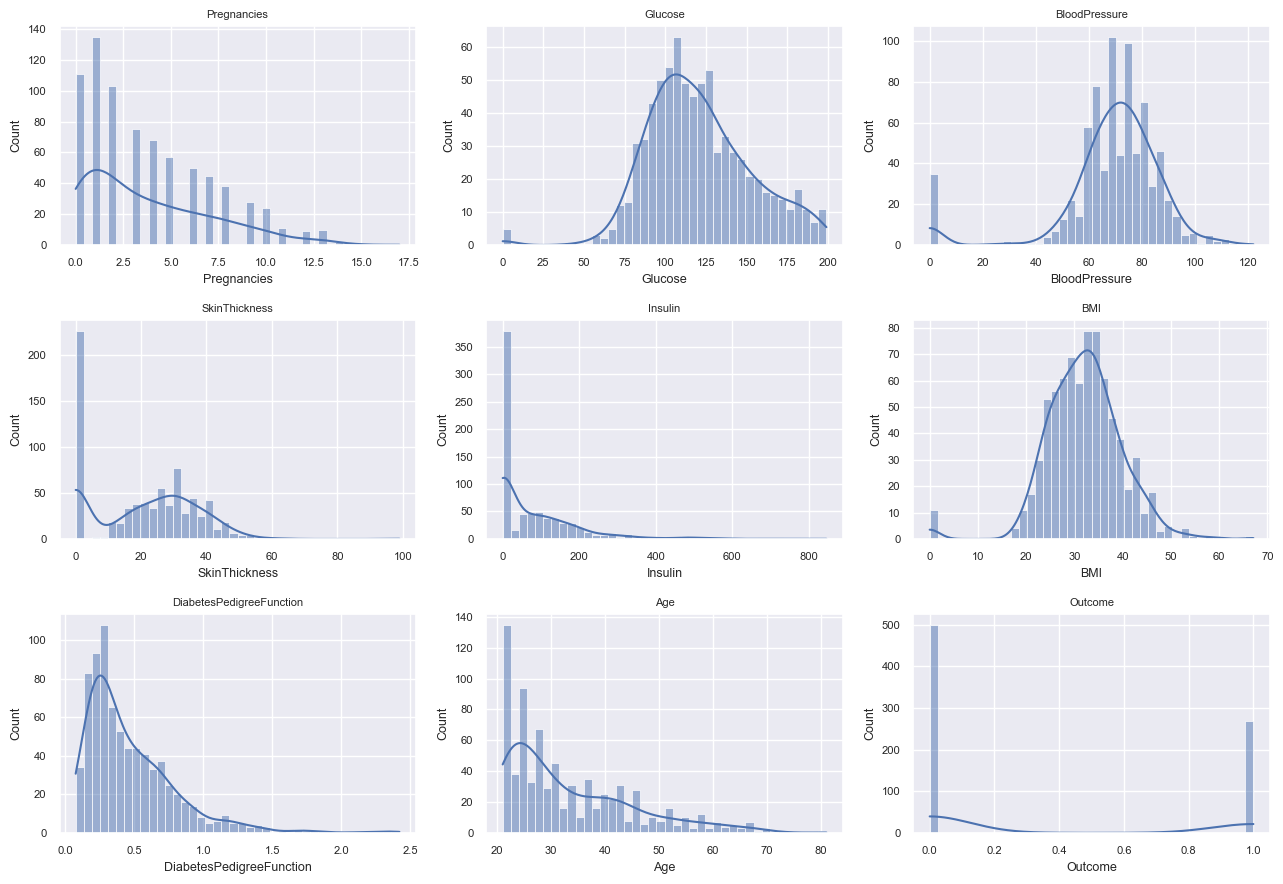

In [ ]:
#Histogram distribution
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for index, col in enumerate(df.columns.tolist()):
    sns.histplot(data=df, x=col, ax=axes[index], kde=True, bins=40)
    axes[index].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

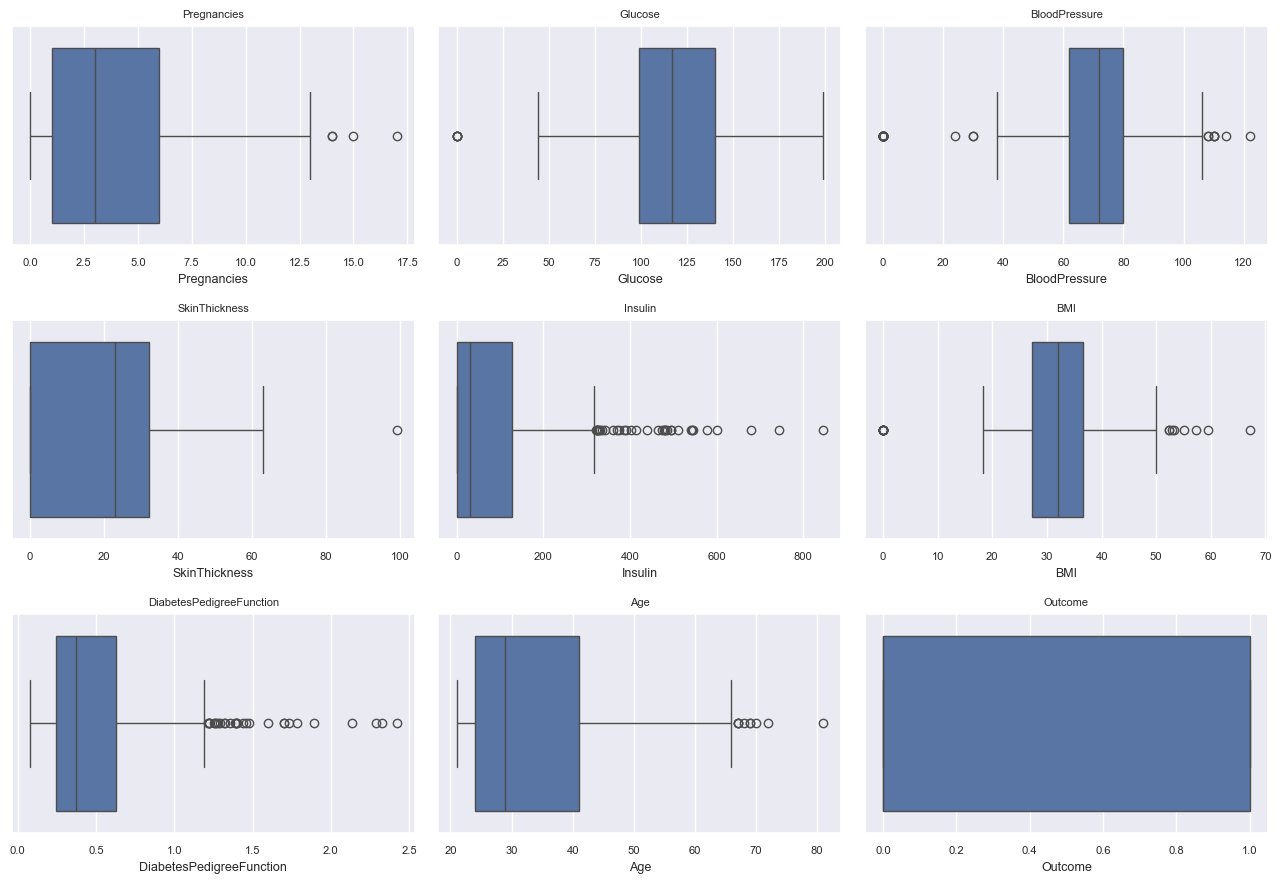

In [ ]:
#Outlier analysis using boxplots
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

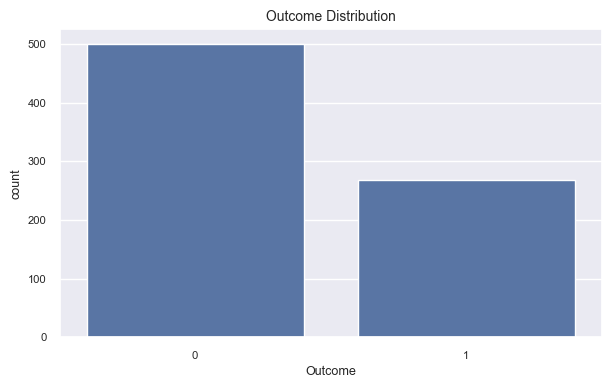

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Outcome Distribution")
plt.show()

**Insulin and DiabetesPedigreeFunction Columns have presence of outliers**
- These outliers are deemed to real world like data, so would not be filled, capped or removed

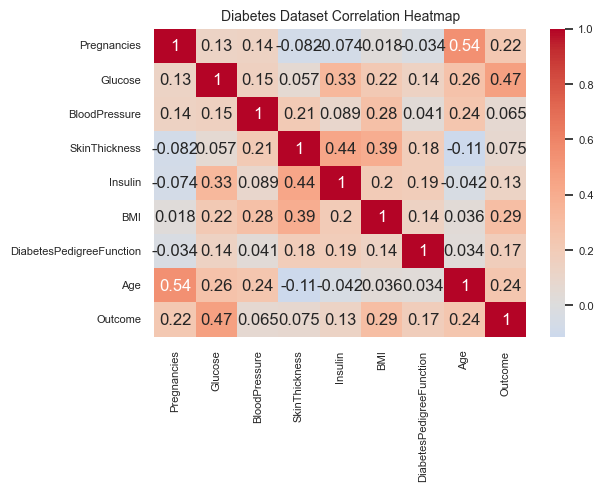

In [ ]:
#Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Diabetes Dataset Correlation Heatmap")
plt.show()

**No multicolinearity**

### 5. Data Preprocessing

In [ ]:
X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

In [ ]:
X[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.600,0.627,50
1,1,85,66,29,0,26.600,0.351,31
2,8,183,64,0,0,23.300,0.672,32
3,1,89,66,23,94,28.100,0.167,21
4,0,137,40,35,168,43.100,2.288,33


In [ ]:
y[:5]

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [ ]:
### train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [ ]:
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape:  (614, 8)
Test shape:  (154, 8)


**Preprocessing Pipeline**

In [ ]:
encoded_cols

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [ ]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_features

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [ ]:
def replace_zeros_with_nan_df(X, cols):
    """
    Replace 0 -> NaN for selected columns in a pandas DataFrame.
    Returns a NEW DataFrame (safe for sklearn pipelines).
    """
    X = X.copy()
    for col in cols:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
    return X


zero_to_nan = FunctionTransformer(
    replace_zeros_with_nan_df,
    kw_args={"cols": encoded_cols},
    validate=False
)


numerical_transformer = Pipeline(
    steps = [
        ("zero_to_nan", zero_to_nan),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocess = ColumnTransformer(
    transformers = [
        ("num", numerical_transformer, numerical_features)
    ]
)


### 6. Baseline Model

In [ ]:
baseline_pipe = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LogisticRegression())
    ]
)

In [ ]:
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [ ]:
baseline_pred_train = baseline_pipe.predict(X_train)
baseline_pred_test = baseline_pipe.predict(X_test)

In [ ]:
def print_evaluation(title: str, ground_truth: np.ndarray, model_predictions: np.ndarray):
    train_acc = accuracy_score(ground_truth, model_predictions)
    train_recall = recall_score(ground_truth, model_predictions)
    train_f1 = f1_score(ground_truth, model_predictions)
    cm = confusion_matrix(ground_truth, model_predictions)

    print("accuracy score: ", train_acc)
    print("recall score: ", train_recall)
    print("f1 score: ", train_f1)
    print("Classification Report:\n", classification_report(ground_truth,model_predictions ))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")
    plt.show()
    

accuracy score:  0.7964169381107492
recall score:  0.5934579439252337
f1 score:  0.6701846965699209
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614



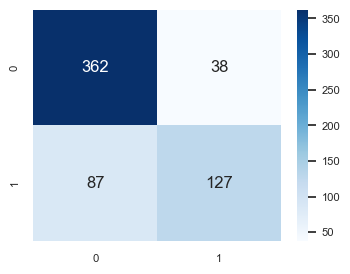

In [ ]:

print_evaluation("BASELINE MODEL TRAINING EVALUATION", y_train, baseline_pred_train)

accuracy score:  0.7077922077922078
recall score:  0.5
f1 score:  0.5454545454545454
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



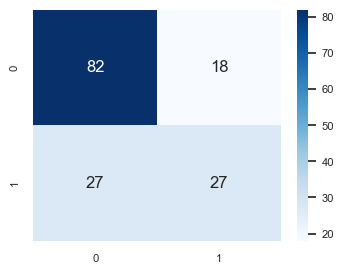

In [ ]:
print_evaluation("BASELINE MODEL TESTING EVALUATION", y_test, baseline_pred_test)

### 7. Model Selection and Training

In [ ]:
k = 10
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
# scale_pos_weight = (# negative samples) / (# positive samples)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1.8691588785046729


In [ ]:
models = {
    "LogisticRegression": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", LogisticRegression(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                max_iter=100
            ))
        ]
    ),
    "DecisonTree": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "RandomForest": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    ),
    "HistGB": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "XGB": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
            ))
        ]
    ),
     "SVC": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", SVC(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
     "KNN": Pipeline(
        steps = [
            ("preprocess", preprocess),
            ("model", KNeighborsClassifier())
        ]
    ),

}

In [ ]:
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [ ]:
scoring = {
    "accuracy_score": "accuracy",
    "recall_score": "recall",
    "f1_score": "f1"
}

In [ ]:
rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy_score"].mean(),
        "recall": scores["test_recall_score"].mean(),
        "f1": scores["test_f1_score"].mean()
    })


cv_result = pd.DataFrame(rows).sort_values("recall", ascending=False)


In [ ]:
cv_result

,model,accuracy,recall,f1
5,SVC,0.756,0.752,0.684
0,LogisticRegression,0.764,0.710,0.677
3,HistGB,0.738,0.650,0.634
4,XGB,0.717,0.608,0.598
6,KNN,0.733,0.585,0.606
1,DecisonTree,0.682,0.561,0.553
2,RandomForest,0.749,0.557,0.605


In [ ]:
best_row = cv_result.iloc[0]
best_model = best_row["model"]
best_model

'SVC'

- LogisticRegression and SVC performance are extremely close

- Decision was made to tune 2 models with each of them

In [ ]:
# Parameter distribution for RandomizedSearchCV
# param_grid_svc = {
#     "model__C": [0.1, 1, 10, 100, 1000],
#     "model__gamma": [0.001, 0.01, 0.1, 1, "scale"]
# }

param_grid_svc = {
    # C controls the trade-off between a smooth decision boundary and classifying points correctly.
    # Testing 3 magnitudes is usually enough to find the right ballpark.
    "model__C": [0.1, 1, 10],
    
    # 'linear' is fast and good for simple data. 
    # 'rbf' is the best default for complex, non-linear data. 
    # (We skip 'poly' and 'sigmoid' because they are rarely better than 'rbf' but add massive computation time).
    "model__kernel": ["linear", "rbf"],
    
    # Gamma only affects the 'rbf' kernel. It defines how far a single data point's influence reaches.
    # 'scale' is an excellent dynamic default calculated by scikit-learn. 
    # We add 0.1 and 1 just in case a tighter or looser boundary is needed.
    "model__gamma": ["scale", 0.1, 1],
    
    # Again, crucial if you have an imbalanced dataset. Remove if perfectly 50/50.
    "model__class_weight": [None, "balanced"]
}


param_grid_logreg = {
    # C is the most important parameter to tune. 
    # Testing these 4 magnitudes covers the vast majority of use cases.
    "model__C": [0.01, 0.1, 1, 10],
    
    # Testing L1 (feature selection) vs L2 (standard regularization) is often where you get performance bumps.
    "model__penalty": ["l1", "l2"],
    
    # 'liblinear' is very fast for small to medium datasets and supports both l1 and l2.
    "model__solver": ["liblinear"],
    
    # Bumping max_iter up ensures the math solver doesn't give up too early (prevents warnings).
    "model__max_iter": [1000]
}









In [ ]:
best_model_pipeline_1 = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", SVC(
            random_state=RANDOM_STATE,
            class_weight="balanced"
            ))
    ]
)



best_model_pipeline_2 = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]
)

In [ ]:
grid1 = GridSearchCV(
    estimator = best_model_pipeline_1,
    param_grid=param_grid_svc,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)


grid2 = GridSearchCV(
    estimator = best_model_pipeline_2,
    param_grid=param_grid_logreg,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)



In [ ]:
grid1.fit(X_train, y_train)#SVC


Fitting 10 folds for each of 36 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 0.1, ...], 'model__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.

In [ ]:
grid2.fit(X_train, y_train)#LogReg

Fitting 10 folds for each of 8 candidates, totalling 80 fits


c:\Users\HP\Desktop\MY PROJECTS\Dr.ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\Desktop\MY PROJECTS\Dr.ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__max_iter': [1000], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [ ]:
print("SVC")
print("Best Score: ", grid1.best_score_)
print("Parameters: ", grid1.best_params_)

print("-"*50)

print("LogisticRegression")
print("Best Score: ", grid2.best_score_)
print("Parameters: ", grid2.best_params_)


SVC
Best Score:  0.7499258503726594
Parameters:  {'model__C': 10, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'linear'}
--------------------------------------------------
LogisticRegression
Best Score:  0.7445594538462303
Parameters:  {'model__C': 10, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


### 7. Retrain Model with best Hyperparameters

In [ ]:
tuned_best_SVC_model = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", SVC(
            random_state=RANDOM_STATE,
            C=1,
            gamma="scale",
            class_weight="balanced",
            kernel="rbf"
        ))
    ]
)

tuned_best_LogReg_model = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            C=1,
            max_iter=1000,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced"
        ))
    ]
)

In [ ]:
tuned_best_SVC_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [ ]:
tuned_best_LogReg_model.fit(X_train, y_train)

c:\Users\HP\Desktop\MY PROJECTS\Dr.ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [ ]:
tuned_SVC_model_pred_train = tuned_best_SVC_model.predict(X_train)
tuned_SVC_model_pred_test = tuned_best_SVC_model.predict(X_test)

In [ ]:
tuned_LogReg_model_pred_train = tuned_best_LogReg_model.predict(X_train)
tuned_LogReg_model_pred_test = tuned_best_LogReg_model.predict(X_test)

accuracy score:  0.8224755700325733
recall score:  0.8504672897196262
f1 score:  0.7695560253699789
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.81      0.86       400
           1       0.70      0.85      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.83       614



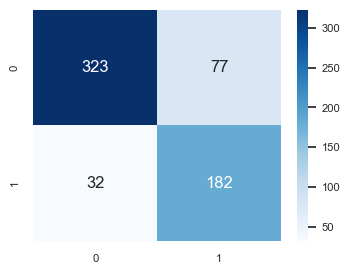

In [ ]:
print_evaluation("SVC TRAINING", y_train,tuned_SVC_model_pred_train)

accuracy score:  0.7272727272727273
recall score:  0.7222222222222222
f1 score:  0.65
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



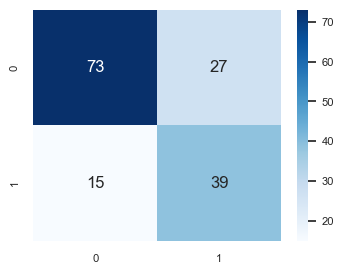

In [ ]:
print_evaluation("SVC TESTING", y_test,tuned_SVC_model_pred_test)

accuracy score:  0.758957654723127
recall score:  0.7102803738317757
f1 score:  0.672566371681416
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       400
           1       0.64      0.71      0.67       214

    accuracy                           0.76       614
   macro avg       0.74      0.75      0.74       614
weighted avg       0.77      0.76      0.76       614



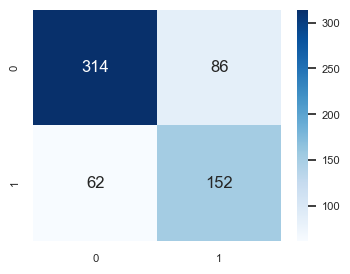

In [ ]:
print_evaluation("LogReg TRAINING", y_train,tuned_LogReg_model_pred_train)

accuracy score:  0.7337662337662337
recall score:  0.7037037037037037
f1 score:  0.6495726495726496
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



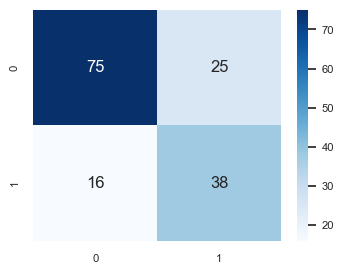

In [ ]:
print_evaluation("LogReg TESTING", y_test,tuned_LogReg_model_pred_test)

### 8. Build a predictive system

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [ ]:
def predict_diabetes(model, input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = model.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Diabetic 🔴")
    else:
        print("Diagnosis - Non-Diabetic 🟢")


In [ ]:
X_test[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159,64,0,0,27.400,0.294,40
672,10,68,106,23,49,35.500,0.285,47
700,2,122,76,27,200,35.900,0.483,26
630,7,114,64,0,0,27.400,0.732,34
81,2,74,0,0,0,0.000,0.102,22


In [ ]:
y_test

44     0
672    0
700    0
630    1
81     0
      ..
32     0
637    0
593    0
425    1
273    0
Name: Outcome, Length: 154, dtype: int64

In [ ]:
y_test[y_test==1].head()

630    1
387    1
408    1
78     1
678    1
Name: Outcome, dtype: int64

In [ ]:
y_test[y_test==0].head()

44     0
672    0
700    0
81     0
389    0
Name: Outcome, dtype: int64

In [ ]:
test1 = X_test.loc[630].tolist()#1
test2 = X_test.loc[44].tolist()#0
test3 = X_test.loc[387].tolist()#1
test4 = X_test.loc[672].tolist()#0

In [ ]:
#Expected output is 1
predict_diabetes(
    tuned_best_SVC_model,
    test1
)

print("-"*50)

predict_diabetes(
    tuned_best_LogReg_model,
    test1
)


print("Expected to be Diabetic")



Model prediction: [1]
Diagnosis - Diabetic 🔴
--------------------------------------------------
Model prediction: [0]
Diagnosis - Non-Diabetic 🟢
Expected to be Diabetic


In [ ]:
#Expected output is 0

predict_diabetes(
    tuned_best_SVC_model,
    test2
)

print("-"*50)


predict_diabetes(
    tuned_best_LogReg_model,
    test2
)


print("Expected to be Non Diabetic")

Model prediction: [1]
Diagnosis - Diabetic 🔴
--------------------------------------------------
Model prediction: [1]
Diagnosis - Diabetic 🔴
Expected to be Non Diabetic


In [ ]:
#Expected output is 1


predict_diabetes(
    tuned_best_SVC_model,
    test3
)
print("-"*50)


predict_diabetes(
    tuned_best_LogReg_model,
    test3
)


print("Expected to be Diabetic")

Model prediction: [0]
Diagnosis - Non-Diabetic 🟢
--------------------------------------------------
Model prediction: [1]
Diagnosis - Diabetic 🔴
Expected to be Diabetic


In [ ]:
#Expected output is 0


predict_diabetes(
    tuned_best_SVC_model,
    test4
)

print("-"*50)


predict_diabetes(
    tuned_best_LogReg_model,
    test4
)

print("Expected to be Non Diabetic")

Model prediction: [0]
Diagnosis - Non-Diabetic 🟢
--------------------------------------------------
Model prediction: [0]
Diagnosis - Non-Diabetic 🟢
Expected to be Non Diabetic


### 9. Saving the trained model

In [ ]:
# from joblib import dump

In [ ]:
# JOBLIB_PATH = r"C:\Users\HP\Desktop\ML\Udemy\section 5(Core Data libraries for ML)\Section 15(ML Projects)\15_9_ASSIGNMENT\save_model_dir\my_diabetes_model.joblib"

In [ ]:
#saving the model which is a Pipeline
# dump(tuned_best_SVC_model, JOBLIB_PATH)
# print(f"Saved with joblib -> {JOBLIB_PATH}")